# Calculating Subobjects of Representable Functors

Nelson Niu  
Nathaniel Osgood  
Priyaa Srinivasan  
Jacob Zelko  
Juxin Liu  
2026-02-26

## Background

Helper method for showing graphviz from quarto markdown:

In [1]:
function show_graphviz(g)
    buf = IOBuffer()
    run_graphviz(buf, g, format="png")
    display(MIME("image/png"), take!(buf))
end

show_graphviz (generic function with 1 method)

## Catlab Set-Up

In [2]:
using CairoMakie
using Images
using MosaicViews

import Catlab.CategoricalAlgebra:
  @acset,
  @acset_type,
  @acset_colim,
  @present,
  ACSetCategory,
  FreeSchema,
  elements,
  incident,
  nparts,
  representable,
  set_subpart!,
  src,
  subobject_classifier,
  tgt,
  yoneda
import Catlab.Graphs:
  NamedGraph,
  add_vertices!,
  add_edges!
import Catlab.Graphics:
  to_graphviz
import Catlab.Graphics.Graphviz: 
  run_graphviz
import Catlab.Models:
  @withmodel
import Catlab.Subobjects:
  Subobject,
  ⟹

## Defining Representables

In [3]:
ng = NamedGraph{Symbol, Symbol}

NamedGraph{Symbol, Symbol}

In [4]:
vset_rep = representable(ng, :V)

V,vname
1,AttrVar(1)


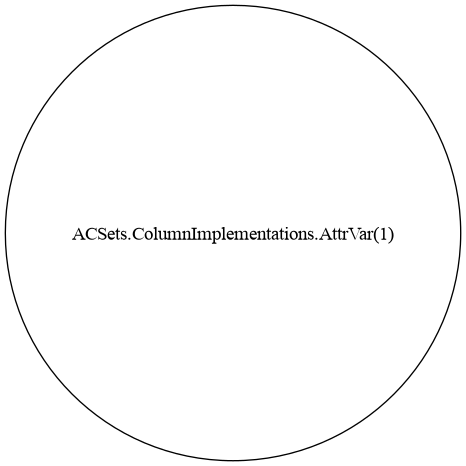

In [5]:
to_graphviz(vset_rep, node_labels = true, edge_labels = true, graph_attrs=Dict(:splines=>"false", :rankdir => "LR")) |> show_graphviz

We next consider the representable for edges

In [6]:
eset_rep = representable(ng, :E)

NamedGraph{Symbol, Symbol} {V:2, E:1, VName:2, EName:1}
┌───┬────────────┐
│ V │      vname │
├───┼────────────┤
│ 1 │ AttrVar(1) │
│ 2 │ AttrVar(2) │
└───┴────────────┘
┌───┬─────┬─────┬────────────┐
│ E │ src │ tgt │      ename │
├───┼─────┼─────┼────────────┤
│ 1 │   2 │   1 │ AttrVar(1) │
└───┴─────┴─────┴────────────┘

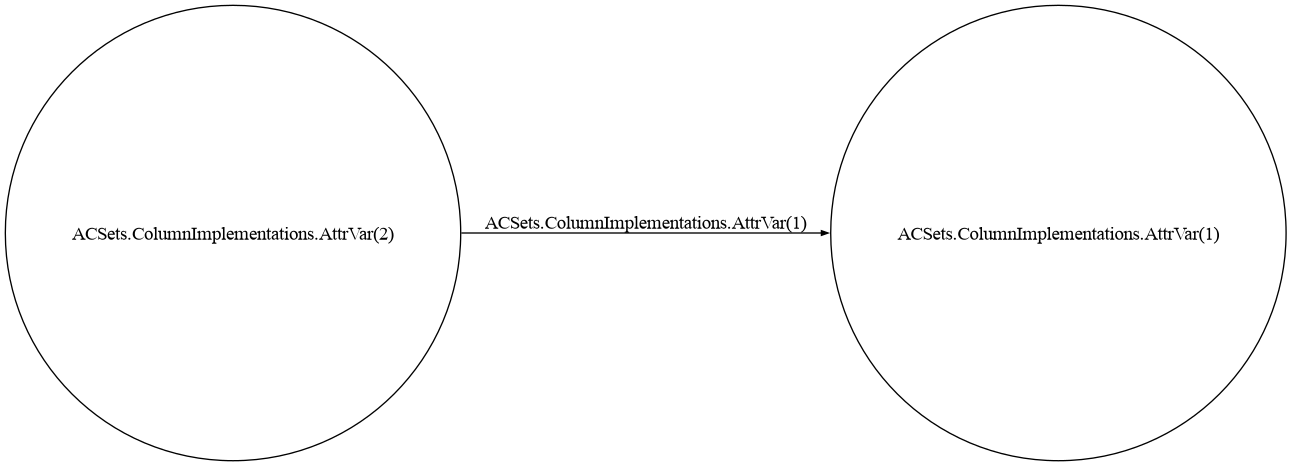

In [7]:
to_graphviz(eset_rep, node_labels = true, edge_labels = true, graph_attrs=Dict(:splines=>"false", :rankdir => "LR")) |> show_graphviz

## Exploring Subobject Classifiers

### Subobject Classifier for Graphs

To allow computation of the subobject classifier for a schema for
graphs, we need to use a schema without attributes. We declare one here.

In [8]:
@present SchMyGrph(FreeSchema) begin
  V::Ob
  E::Ob
  src::Hom(E,V)
  tgt::Hom(E,V)
end;

In [9]:
@acset_type MyGrph(SchMyGrph, index=[:src, :tgt])

MyGrph

In [10]:
representable(MyGrph, :V)

MyGrph {V:1, E:0}

In [11]:
representable(MyGrph, :E)

E,src,tgt
1,2,1


In [12]:
ΩGraph, dictΩGraph = subobject_classifier(MyGrph)

(MyGrph:
  V = 1:2
  E = 1:5
  src : E → V = [1, 1, 1, 2, 2]
  tgt : E → V = [1, 1, 2, 1, 2], Dict{Catlab.Theories.FreeSchema.Ob{:generator}, Vector{Subobject}}(E => [Catlab.CategoricalAlgebra.Cats.Subobjects.SubobjectHom{MyGrph, Catlab.CategoricalAlgebra.Pointwise.ACSetTransformations.StructACSetTransformation{ACSets.Schemas.TypeLevelBasicSchema{Symbol, Tuple{:V, :E}, Tuple{(:src, :E, :V), (:tgt, :E, :V)}, Tuple{}, Tuple{}, Tuple{}}, @NamedTuple{V::Catlab.BasicSets.FinFunctions.FinFunction, E::Catlab.BasicSets.FinFunctions.FinFunction}, MyGrph, MyGrph}}(ACSetTransformation((V = id(FinSet(2)), E = id(FinSet(1))), )), Catlab.CategoricalAlgebra.Cats.Subobjects.SubobjectHom{MyGrph, Catlab.CategoricalAlgebra.Pointwise.ACSetTransformations.StructACSetTransformation{ACSets.Schemas.TypeLevelBasicSchema{Symbol, Tuple{:V, :E}, Tuple{(:src, :E, :V), (:tgt, :E, :V)}, Tuple{}, Tuple{}, Tuple{}}, @NamedTuple{V::Catlab.BasicSets.FinFunctions.FinFunction, E::Catlab.BasicSets.FinFunctions.FinFunction}

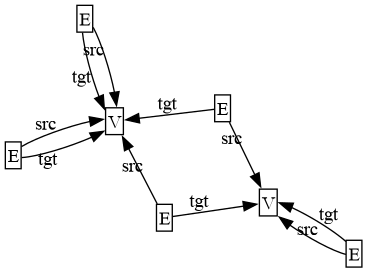

In [13]:
to_graphviz(elements(ΩGraph)) |> show_graphviz

### Subobject Classifier for Symmetric Graphs

Now we examine the representable for a symmetric graph

In [14]:
@present SchSymmetricGrph(FreeSchema) begin
  V::Ob
  E::Ob
  src::Hom(E,V)
  tgt::Hom(E,V)
  inv::Hom(E,E)

  compose(inv,inv) == id(E)
  compose(inv,src) == tgt
  compose(inv,tgt) == src
end;

In [15]:
@acset_type SchSymmetricInstance(SchSymmetricGrph)

SchSymmetricInstance

In [16]:
representable(SchSymmetricInstance, :V)

SchSymmetricInstance {V:1, E:0}

In [17]:
representable(SchSymmetricInstance, :E)

E,src,tgt,inv
1,1,2,2
2,2,1,1


In [18]:
ΩSymGraph, dictΩSymGraph = subobject_classifier(SchSymmetricInstance)

(SchSymmetricInstance:
  V = 1:2
  E = 1:5
  src : E → V = [1, 1, 2, 1, 2]
  tgt : E → V = [1, 1, 1, 2, 2]
  inv : E → E = [1, 2, 4, 3, 5], Dict{Catlab.Theories.FreeSchema.Ob{:generator}, Vector{Subobject}}(E => [Catlab.CategoricalAlgebra.Cats.Subobjects.SubobjectHom{SchSymmetricInstance, Catlab.CategoricalAlgebra.Pointwise.ACSetTransformations.StructACSetTransformation{ACSets.Schemas.TypeLevelBasicSchema{Symbol, Tuple{:V, :E}, Tuple{(:src, :E, :V), (:tgt, :E, :V), (:inv, :E, :E)}, Tuple{}, Tuple{}, Tuple{(nothing, :E, :E, ((:inv, :inv), ())), (nothing, :E, :V, ((:inv, :src), (:tgt,))), (nothing, :E, :V, ((:inv, :tgt), (:src,)))}}, @NamedTuple{V::Catlab.BasicSets.FinFunctions.FinFunction, E::Catlab.BasicSets.FinFunctions.FinFunction}, SchSymmetricInstance, SchSymmetricInstance}}(ACSetTransformation((V = id(FinSet(2)), E = id(FinSet(2))), )), Catlab.CategoricalAlgebra.Cats.Subobjects.SubobjectHom{SchSymmetricInstance, Catlab.CategoricalAlgebra.Pointwise.ACSetTransformations.StructACSetT

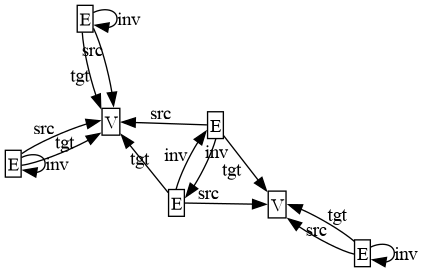

In [19]:
to_graphviz(elements(ΩSymGraph)) |> show_graphviz

## Subobject Classifiers for the Zig-Zag Schema

### Subobject Classifier for $2$ Timepoints

Zig-zag schema for 2 timepoints

In [20]:
@present ZigZag2Timepoints(FreeSchema) begin
  (t0,t1)::Ob
  (t0_to_t1)::Ob
  t0_incl::Hom(t0,t0_to_t1)
  t1_incl::Hom(t1,t0_to_t1)
end;

In [21]:
@acset_type ZigZag2TimepointsInstance(ZigZag2Timepoints)

ZigZag2TimepointsInstance

In [22]:
yoneda(ZigZag2TimepointsInstance)

Catlab.CategoricalAlgebra.Cats.FinFunctors.FinDomMap.FinDomFunctorMap{Union{Catlab.Theories.FreeSchema.AttrType{:generator}, Catlab.Theories.FreeSchema.Ob{:generator}}, ACSets.ACSetInterface.ACSet, Union{Catlab.Theories.FreeSchema.Attr, Catlab.Theories.FreeSchema.Hom}, Catlab.CategoricalAlgebra.Pointwise.ACSetTransformations.ACSetTransformation, Union{Catlab.Theories.FreeSchema.Attr{:generator}, Catlab.Theories.FreeSchema.Hom{:generator}}, Dict{Catlab.Theories.FreeSchema.Ob{:generator}, ZigZag2TimepointsInstance}, Dict{Catlab.Theories.FreeSchema.Hom{:generator}, Catlab.CategoricalAlgebra.Pointwise.ACSetTransformations.StructACSetTransformation{ACSets.Schemas.TypeLevelBasicSchema{Symbol, Tuple{:t0, :t1, :t0_to_t1}, Tuple{(:t0_incl, :t0, :t0_to_t1), (:t1_incl, :t1, :t0_to_t1)}, Tuple{}, Tuple{}, Tuple{}}, @NamedTuple{t0::Catlab.BasicSets.FinFunctions.FinFunction, t1::Catlab.BasicSets.FinFunctions.FinFunction, t0_to_t1::Catlab.BasicSets.FinFunctions.FinFunction}, ZigZag2TimepointsInstance

In [23]:
hT0_2TP = representable(ZigZag2TimepointsInstance, :t0)

t0,t0_incl
1,1


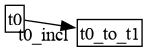

In [24]:
to_graphviz(elements(hT0_2TP)) |> show_graphviz

In [25]:
hT1_2TP = representable(ZigZag2TimepointsInstance, :t1)

t1,t1_incl
1,1


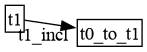

In [26]:
to_graphviz(elements(hT1_2TP)) |> show_graphviz

In [27]:
hT0_to_T1_2TP = representable(ZigZag2TimepointsInstance, :t0_to_t1)

ZigZag2TimepointsInstance {t0:0, t1:0, t0_to_t1:1}

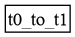

In [28]:
to_graphviz(elements(hT0_to_T1_2TP)) |> show_graphviz

In [29]:
ΩZZ2TP, dictΩZZ2TP = subobject_classifier(ZigZag2TimepointsInstance)

(ZigZag2TimepointsInstance:
  t0 = 1:3
  t1 = 1:3
  t0_to_t1 = 1:2
  t0_incl : t0 → t0_to_t1 = [1, 1, 2]
  t1_incl : t1 → t0_to_t1 = [1, 1, 2], Dict{Catlab.Theories.FreeSchema.Ob{:generator}, Vector{Subobject}}(t0 => [Catlab.CategoricalAlgebra.Cats.Subobjects.SubobjectHom{ZigZag2TimepointsInstance, Catlab.CategoricalAlgebra.Pointwise.ACSetTransformations.StructACSetTransformation{ACSets.Schemas.TypeLevelBasicSchema{Symbol, Tuple{:t0, :t1, :t0_to_t1}, Tuple{(:t0_incl, :t0, :t0_to_t1), (:t1_incl, :t1, :t0_to_t1)}, Tuple{}, Tuple{}, Tuple{}}, @NamedTuple{t0::Catlab.BasicSets.FinFunctions.FinFunction, t1::Catlab.BasicSets.FinFunctions.FinFunction, t0_to_t1::Catlab.BasicSets.FinFunctions.FinFunction}, ZigZag2TimepointsInstance, ZigZag2TimepointsInstance}}(ACSetTransformation((t0 = id(FinSet(1)), t1 = id(FinSet(0)), t0_to_t1 = id(FinSet(1))), )), Catlab.CategoricalAlgebra.Cats.Subobjects.SubobjectHom{ZigZag2TimepointsInstance, Catlab.CategoricalAlgebra.Pointwise.ACSetTransformations.StructAC

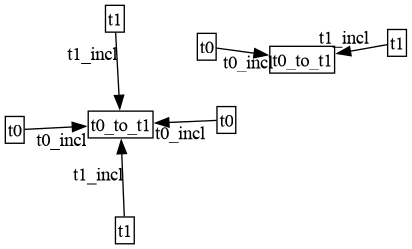

In [30]:
to_graphviz(elements(ΩZZ2TP)) |> show_graphviz

#### Work in Progress

I was attempting to enumerate the subobjects found within this interval.
There are 8 total subobjects without accounting for the constraints –
with the constraints, there are actually only 5 subobjects. These
constraints come into play on the “edges” of the interval (i.e. $t_{0}$
and $t_{1}$).

I am able to extract the 8 subobjects from within the `dictΩZZ2TP`
associated to each object on the interval span. What I would like to do
is:

1.  Enforce the constraints so as to only recover 5 subobjects.

2.  Interpret the subobjects as graphs with 2 vertices and 1 directed
    edge.

3.  Extract truth values associated with each subobject’s representable.

4.  Color vertex 1, vertex 2, or the edge to correspond to truth values
    on the subobject.

5.  Perform logic between subobjects so as to combine with [the last
    section](#calculating-truth-tables-for-subobjects-of-representables)

Per Nelson Niu, there is a Kan extension that exists such that we can
have an adjunction from Zop to Gr so that we could have object 2 and 4.
Then, since we would be working with graphs, it should be
straightforward to do 5. Yet, I am blocked.

    test_key_t1 = dictΩZZ2TP.keys[16]
    test_key_t0 = dictΩZZ2TP.keys[11]
    test_key_t0t1 = dictΩZZ2TP.keys[14]

    t0_subobs = Subobject.(dictΩZZ2TP[test_key_t0] .|> ob, dictΩZZ2TP[test_key_t0] .|> components)

    t1_subobs = Subobject.(dictΩZZ2TP[test_key_t1] .|> ob, dictΩZZ2TP[test_key_t1] .|> components)

    t0t1_subobs = Subobject.(dictΩZZ2TP[test_key_t0t1] .|> ob, dictΩZZ2TP[test_key_t0t1] .|> components)

    subobs = []
    push!(subobs, t0_subobs...)
    push!(subobs, t1_subobs...)
    push!(subobs, t0t1_subobs...)

    subobject_pairs = [(b, c) for b in reverse(subobs), c in subobs];
    @withmodel ACSetCategory(ZigZag2TimepointsInstance()) (⟹) begin
        for (idx, pair) in enumerate(subobject_pairs)
            representative = pair[1] ⟹ pair[2]
            open("graph_$(idx).png", "w") do io
                run_graphviz(io, to_graphviz(representative, graph_attrs=Dict(:dpi => "300")), format="png")
            end
        end
    end

### Subobject Classifier for $4$ Timepoints

Now we examine the impact of a size 4 category

In [31]:
@present ZigZag4Timepoints(FreeSchema) begin
  (t0,t1,t2,t3)::Ob
  (t0_to_t1, t1_to_t2, t2_to_t3)::Ob

  t0_inclS::Hom(t0,t0_to_t1)
  t1_inclF::Hom(t1,t0_to_t1)

  t1_inclS::Hom(t1,t1_to_t2)
  t2_inclF::Hom(t2,t1_to_t2)

  t2_inclS::Hom(t2,t2_to_t3)
  t3_inclF::Hom(t3,t2_to_t3)
end;

In [32]:
@acset_type ZigZag4TimepointsInstance2(ZigZag4Timepoints)

ZigZag4TimepointsInstance2

In [33]:
yoneda(ZigZag4TimepointsInstance2)

Catlab.CategoricalAlgebra.Cats.FinFunctors.FinDomMap.FinDomFunctorMap{Union{Catlab.Theories.FreeSchema.AttrType{:generator}, Catlab.Theories.FreeSchema.Ob{:generator}}, ACSets.ACSetInterface.ACSet, Union{Catlab.Theories.FreeSchema.Attr, Catlab.Theories.FreeSchema.Hom}, Catlab.CategoricalAlgebra.Pointwise.ACSetTransformations.ACSetTransformation, Union{Catlab.Theories.FreeSchema.Attr{:generator}, Catlab.Theories.FreeSchema.Hom{:generator}}, Dict{Catlab.Theories.FreeSchema.Ob{:generator}, ZigZag4TimepointsInstance2}, Dict{Catlab.Theories.FreeSchema.Hom{:generator}, Catlab.CategoricalAlgebra.Pointwise.ACSetTransformations.StructACSetTransformation{ACSets.Schemas.TypeLevelBasicSchema{Symbol, Tuple{:t0, :t1, :t2, :t3, :t0_to_t1, :t1_to_t2, :t2_to_t3}, Tuple{(:t0_inclS, :t0, :t0_to_t1), (:t1_inclF, :t1, :t0_to_t1), (:t1_inclS, :t1, :t1_to_t2), (:t2_inclF, :t2, :t1_to_t2), (:t2_inclS, :t2, :t2_to_t3), (:t3_inclF, :t3, :t2_to_t3)}, Tuple{}, Tuple{}, Tuple{}}, @NamedTuple{t2_to_t3::Catlab.Basic

In [34]:
hT0_4TP = representable(ZigZag4TimepointsInstance2, :t0)

t0,t0_inclS
1,1


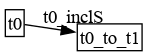

In [35]:
to_graphviz(elements(hT0_4TP)) |> show_graphviz

In [36]:
hT1_4TP = representable(ZigZag4TimepointsInstance2, :t1)

t1,t1_inclF,t1_inclS
1,1,1


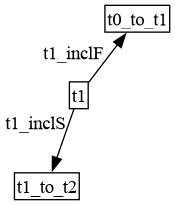

In [37]:
to_graphviz(elements(hT1_4TP)) |> show_graphviz

In [38]:
ΩZZ4TP,dictΩZZ4TP  = subobject_classifier(ZigZag4TimepointsInstance2)

(ZigZag4TimepointsInstance2:
  t0 = 1:3
  t1 = 1:5
  t2 = 1:5
  t3 = 1:3
  t0_to_t1 = 1:2
  t1_to_t2 = 1:2
  t2_to_t3 = 1:2
  t0_inclS : t0 → t0_to_t1 = [1, 1, 2]
  t1_inclF : t1 → t0_to_t1 = [1, 1, 1, 2, 2]
  t1_inclS : t1 → t1_to_t2 = [1, 1, 2, 1, 2]
  t2_inclF : t2 → t1_to_t2 = [1, 1, 1, 2, 2]
  t2_inclS : t2 → t2_to_t3 = [1, 1, 2, 1, 2]
  t3_inclF : t3 → t2_to_t3 = [1, 1, 2], Dict{Catlab.Theories.FreeSchema.Ob{:generator}, Vector{Subobject}}(t2 => [Catlab.CategoricalAlgebra.Cats.Subobjects.SubobjectHom{ZigZag4TimepointsInstance2, Catlab.CategoricalAlgebra.Pointwise.ACSetTransformations.StructACSetTransformation{ACSets.Schemas.TypeLevelBasicSchema{Symbol, Tuple{:t0, :t1, :t2, :t3, :t0_to_t1, :t1_to_t2, :t2_to_t3}, Tuple{(:t0_inclS, :t0, :t0_to_t1), (:t1_inclF, :t1, :t0_to_t1), (:t1_inclS, :t1, :t1_to_t2), (:t2_inclF, :t2, :t1_to_t2), (:t2_inclS, :t2, :t2_to_t3), (:t3_inclF, :t3, :t2_to_t3)}, Tuple{}, Tuple{}, Tuple{}}, @NamedTuple{t2_to_t3::Catlab.BasicSets.FinFunctions.FinFunction,

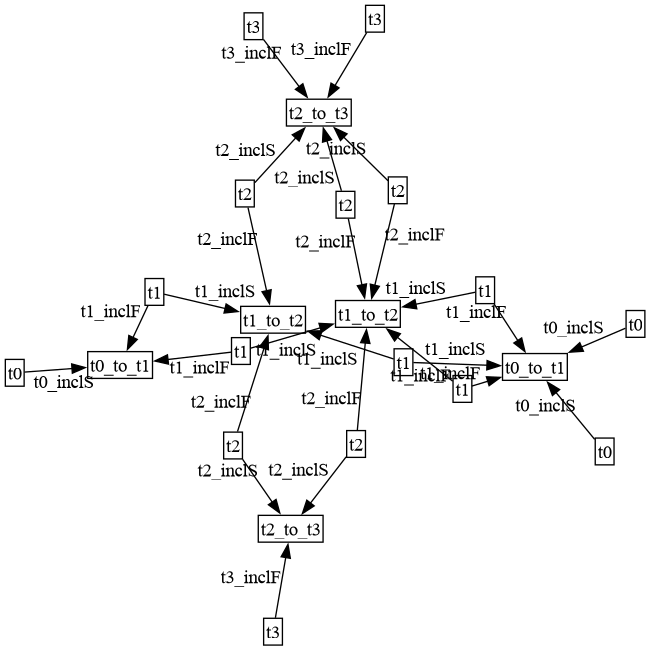

In [39]:
to_graphviz(elements(ΩZZ4TP)) |> show_graphviz

## Calculating Truth Tables for Subobjects of Representables

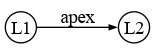

In [40]:
G = NamedGraph{Symbol, Symbol}()

add_vertices!(
    G,
    2
)

set_subpart!(G, :vname, [:L1, :L2]);

add_edges!(
    G,
    [1],
    [2],
    ename = :apex
)

to_graphviz(G, node_labels = true, edge_labels = true, graph_attrs=Dict(:splines=>"false", :rankdir => "LR")) |> show_graphviz

In [41]:
S1 = Subobject(G, V = [])
S2 = Subobject(G, V = incident(G, :L1, :vname))
S3 = Subobject(G, V = incident(G, :L2, :vname))
S4 = Subobject(G, V = vcat(incident(G, :L1, :vname), incident(G, :L2, :vname)))
S5 = Subobject(G, V = vcat(incident(G, :L1, :vname), incident(G, :L2, :vname)), E = incident(G, :apex, :ename))

subobjects = [S1, S2, S3, S4, S5];

In [42]:
subobjects .|> x -> to_graphviz(x, graph_attrs=Dict(:splines=>"false", :rankdir => "LR")) |> show_graphviz

5-element Vector{Nothing}:
 nothing
 nothing
 nothing
 nothing
 nothing

In [43]:
subobject_pairs = [(b, c) for b in reverse(subobjects), c in subobjects];

In [44]:
@withmodel ACSetCategory(NamedGraph{Symbol, Symbol}()) (⟹) begin
    for (idx, pair) in enumerate(subobject_pairs)
        representative = pair[1] ⟹ pair[2]
        open("graph_$(idx).png", "w") do io
            run_graphviz(io, to_graphviz(representative, graph_attrs=Dict(:dpi => "300")), format="png")
        end
    end
end

In [45]:
imgs = [CairoMakie.load("graph_$i.png") for i in 1:25];

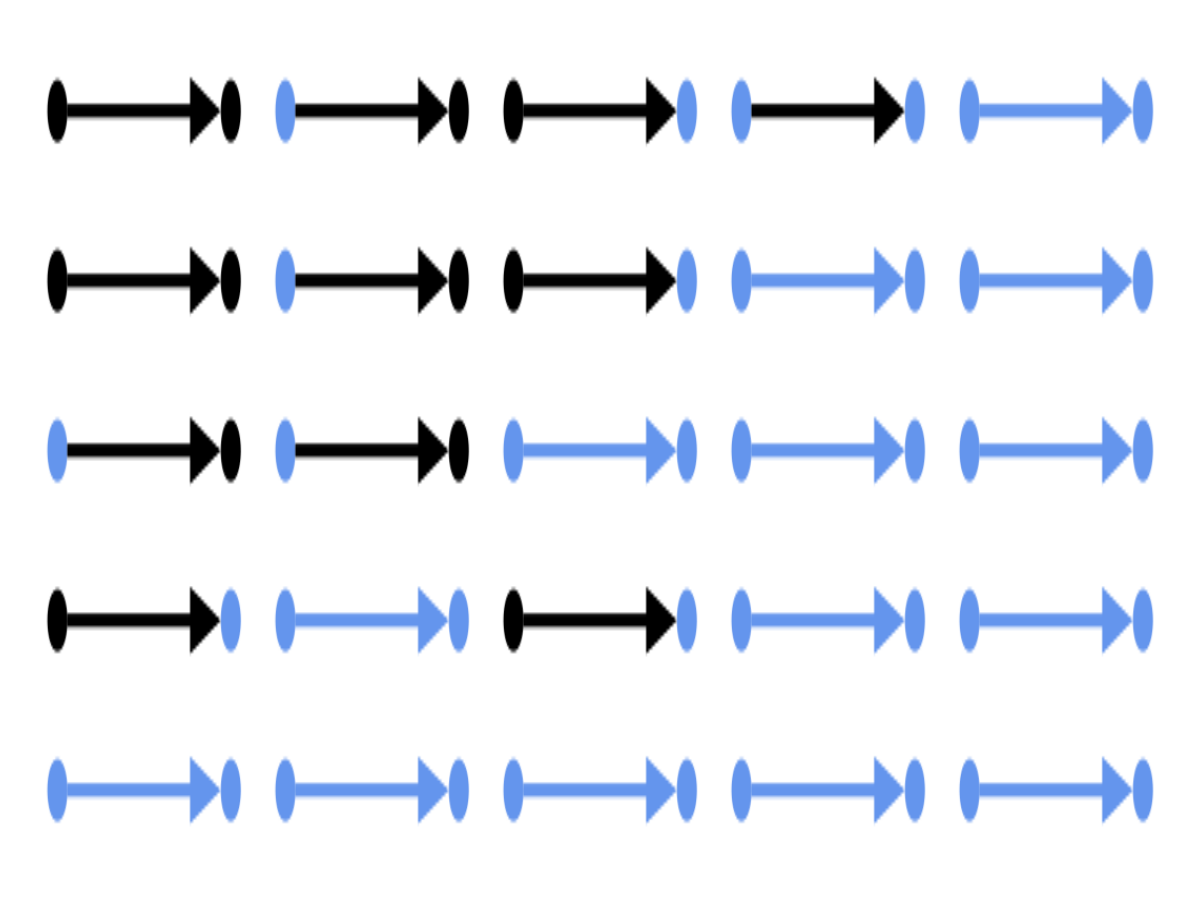

CairoMakie.Screen{IMAGE}


In [46]:
m = mosaicview(imgs, nrow=5, ncol=5, npad=4, fillvalue=colorant"white")

fig, ax, plt = CairoMakie.image(rotr90(m))
hidedecorations!(ax)
hidespines!(ax)
display(fig)